,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Categorical features detected: ['cut', 'color', 'clarity']
Unique categories per feature before encoding:
cut: <StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str
color: <StringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str
clarity: <StringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str
Number of samples: 53940
Number of features before encoding and scaling: 9
Number of encoded features after dropping first category: 17
Number of features used in model: 23
Mean Squared Error (Linear Regression): 1288705.48
R-squared Score (Linear Regression): 0.9189
Mean Squared Error (Ridge Regression, alpha=1): 1288659.47
R-squared Score (Ridge Regression, alpha=1): 0.9189


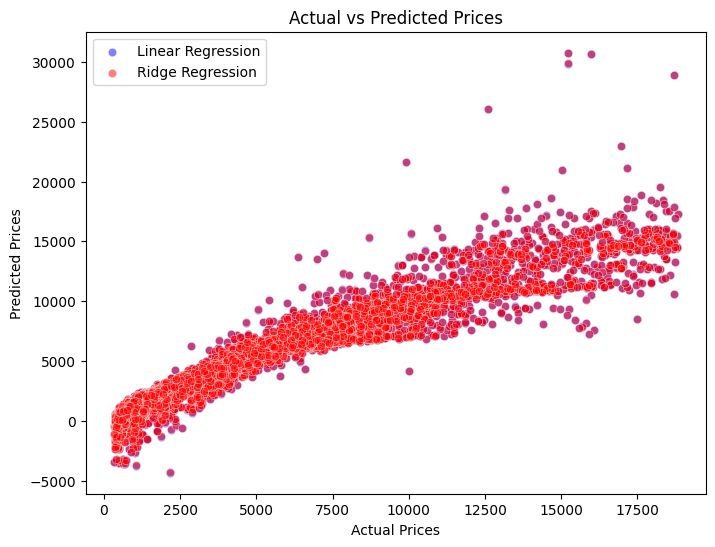

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load the Diamonds dataset from seaborn
df = sns.load_dataset("diamonds")

# Display first few rows before preprocessing
display(df.head())

# Drop irrelevant columns and handle missing values
df.dropna(inplace=True)  # Removing missing values

# Manually define categorical features (ensure they are correctly detected)
categorical_features = ["cut", "color", "clarity"]  # Explicitly specifying categorical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.drop("price")

# Convert categorical features to string (if they were mistakenly numerical)
for col in categorical_features:
    df[col] = df[col].astype(str)

# Print detected categorical features
print("Categorical features detected:", categorical_features)

# Verify unique values in categorical features
print("Unique categories per feature before encoding:")
for col in categorical_features:
    print(f"{col}: {df[col].unique()}")

# Print the number of samples and features before encoding and scaling
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features before encoding and scaling: {df.shape[1] - 1}")  # Excluding target variable

# TODO: Task 1 - Uncomment the following section to apply One-Hot Encoding and Feature Scaling
# Instructions:
# - Uncomment the code below.
# - Run the program and compare results with and without encoding/scaling.

from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Encode categorical variables using One-Hot Encoding
encoder = OneHotEncoder(drop="first", sparse_output=False)  # Drop first category to avoid redundancy.
categorical_encoded = encoder.fit_transform(df[categorical_features])

# Convert encoded features into a DataFrame with proper column names
categorical_encoded_df = pd.DataFrame(
    categorical_encoded,
    columns=encoder.get_feature_names_out(input_features=categorical_features),
)

# Print the number of encoded features after dropping the first category
print(f"Number of encoded features after dropping first category: {categorical_encoded_df.shape[1]}")

# Standardize numerical features to bring them to the same scale
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(df[numerical_features])
numerical_scaled_df = pd.DataFrame(numerical_scaled, columns=numerical_features)

# Combine processed features into a single dataset
X = pd.concat([numerical_scaled_df, categorical_encoded_df], axis=1)

# ---- TEMPORARY: Using raw numerical data ----
# TODO: Task 1: Comment the following line to use the encoded and scaled features
# Since encoding and scaling are commented out, we will use only numerical features without transformation.
# X = df[numerical_features]  # Directly using numerical features without transformation

# Task 1 observations: With encoding/scaling, the model uses categorical signals and
# numerical features contribute on comparable scales. This usually improves R-squared
# and lowers MSE compared to using only raw numeric columns.
# Advantage: encoding makes categories usable; scaling prevents large-magnitude
# features from dominating and helps regularization behave consistently.

# Target variable
y = df["price"]

# Print the number of features after skipping encoding and scaling
print(f"Number of features used in model: {X.shape[1]}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# TODO: Task 2 - Uncomment the following section to apply Ridge Regularization (L2)
# Instructions:
# - Uncomment the code below.
# - Compare results with and without regularization.
# - Adjust the alpha parameter to see how regularization strength affects performance.

alpha_value = 1  # Regularization strength, can be adjusted
ridge_model = Ridge(alpha=alpha_value)
ridge_model.fit(X_train, y_train)

# Predict on test set using Ridge Regression
y_pred_ridge = ridge_model.predict(X_test)

# Predict on test set using Linear Regression
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (Linear Regression): {mse:.2f}")
print(f"R-squared Score (Linear Regression): {r2:.4f}")

# TODO: Task 2 - Evaluate Ridge Regression
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Mean Squared Error (Ridge Regression, alpha={alpha_value}): {mse_ridge:.2f}")
print(f"R-squared Score (Ridge Regression, alpha={alpha_value}): {r2_ridge:.4f}")

# Task 2 observations: As alpha -> 0, Ridge matches ordinary least squares, so MSE and R-squared
# are nearly the same. As alpha grows large, coefficients shrink toward 0, predictions become
# less responsive to features, MSE rises and R-squared drops (underfitting). A moderate alpha
# can slightly improve test performance by reducing variance and sensitivity to correlated features.
# Advantage of regularization: it discourages overly large coefficients, reduces overfitting,
# and makes the model more stable when predictors are correlated or noisy.

# Plot actual vs predicted values
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, label="Linear Regression", color="blue")

# TODO: Task 2 - Add Ridge Regression to the plot
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.5, label="Ridge Regression", color="red")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()

# ---- LAB EXERCISE INSTRUCTIONS ----
# Step 1: Run the code as it is and note the model performance.
# Step 2: Uncomment Task 1 (Encoding and Scaling), run again, and compare results.
# Step 3: Uncomment Task 2 (Ridge Regularization), run again, and compare results.
# Step 4: Adjust the alpha value in Ridge Regression to observe its effect on performance.


In [ ]:
# Task 1 observations: With encoding/scaling, the model uses categorical signals and
# numerical features contribute on comparable scales. This usually improves R-squared
# and lowers MSE compared to using only raw numeric columns.
# Advantage: encoding makes categories usable; scaling prevents large-magnitude
# features from dominating and helps regularization behave consistently.

# Task 2 observations: As alpha - 0, Ridge matches ordinary least squares, so MSE and R-squared
# are nearly the same. As alpha grows large, coefficients shrink toward 0, predictions become
# less responsive to features, MSE rises and R-squared drops (underfitting). A moderate alpha
# can slightly improve test performance by reducing variance and sensitivity to correlated features.
# Advantage of regularization: it discourages overly large coefficients, reduces overfitting,
# and makes the model more stable when predictors are correlated or noisy.